# Glitter (PIV): visualización de un análisis

Lee lo que guarda **ANALIZAR TODO** (TouchDesigner): una carpeta por análisis,
`fluido/data glitter/<grabación>/<fecha del análisis>/`, con

- `parametros.json`: calibración, colores, tiempos y parámetros del PIV de cada cámara.
- `camara<L>_campo.csv`: una fila por vector de cada par de cuadros
  (`frame, t_s, x_px, y_px, x_mm, y_mm, u_mm_s, v_mm_s, interpolado`).
- `camara<L>_centro.csv`: el centro del vórtice en cada par
  (`frame, t_s, xc_px, yc_px, xc_mm, yc_mm, seguido, area_px`). Sale de seguir la partícula
  central; si el seguimiento estaba apagado, es el centro marcado a mano.
- `imagenes/`: las etapas del procesamiento de algún par (no se usan acá).

Todo se pasa a **cm** con la calibración hecha en TouchDesigner. Si una cámara no se calibró,
sus gráficos quedan en px y se avisa. El origen está abajo a la izquierda con `y` hacia arriba,
así que un giro antihorario tiene `v_θ > 0`.

Correr las celdas en orden. Lo único para tocar son las variables en MAYÚSCULAS.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
fontsize = 13
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": fontsize,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fontsize": fontsize,
        "mathtext.default": "regular",
        "mathtext.fontset": "cm",
        "legend.frameon": True,
    }
)
AZUL, NARANJA = "#2A6FB5", "#E08A2E"

DATA = Path("../data glitter")

# Una carpeta por análisis: <grabación>/<fecha del análisis>/parametros.json
analisis = sorted(DATA.glob("*/*/parametros.json"), key=lambda p: p.parent.name)
for i, p in enumerate(analisis):
    print(f"{i - len(analisis):4d}   {p.parent.parent.name}  /  {p.parent.name}")

  -2   2026-09-14_135212_SIMULACION  /  2026-09-15_164117
  -1   2026-09-16_161424_particula_prueba  /  2026-09-16_162638


## 1. Cargar

- `CUAL`: el número de la lista de arriba (`-1` = el análisis más reciente).
- `SACAR_INTERPOLADOS`: dejar afuera de los promedios los vectores que la validación descartó
  y rellenó con sus vecinos.
- `RESTAR_VELOCIDAD_DEL_CENTRO`: si el centro se mueve, todo el vórtice se traslada con él.
  Restando la velocidad del centro, `v_θ` y `v_r` quedan medidos en el sistema del vórtice.

Para cada vector se calcula la posición respecto del centro **de ese par** (`dx, dy, r`) y las
velocidades tangencial `vt` y radial `vr`.

In [2]:
CUAL = -1
SACAR_INTERPOLADOS = True
RESTAR_VELOCIDAD_DEL_CENTRO = True

CARPETA = analisis[CUAL].parent
P = json.loads(analisis[CUAL].read_text(encoding="utf-8"))
info = P["grabacion_info"]


def cargar_centro(cam, k, cx_fijo, cy_fijo, frames):
    # Centro por par (en cm o px) y su velocidad. Sin _centro.csv: el centro marcado, quieto.
    ruta = CARPETA / cam["csv_centro"] if "csv_centro" in cam else None
    if ruta is None or not ruta.exists():
        return pd.DataFrame({"frame": frames, "xc": cx_fijo, "yc": cy_fijo, "seguido": 0,
                             "uc": 0.0, "vc": 0.0}).set_index("frame")
    c = pd.read_csv(ruta).set_index("frame")
    c["xc"], c["yc"] = c["xc_mm"] * k, c["yc_mm"] * k
    c["uc"] = np.gradient(c["xc"], c["t_s"])
    c["vc"] = np.gradient(c["yc"], c["t_s"])
    return c


def cargar(L, cam):
    cal = cam["calibracion"]
    calibrada = cal["mm_por_px"] is not None
    k = 0.1 if calibrada else 1.0                    # mm -> cm (sin calibrar, las columnas "mm" estan en px)
    s = cal["mm_por_px"] * k if calibrada else 1.0   # cm (o px) por px

    todo = pd.read_csv(CARPETA / cam["csv"])
    todo["x"], todo["y"] = todo["x_mm"] * k, todo["y_mm"] * k
    todo["u"], todo["v"] = todo["u_mm_s"] * k, todo["v_mm_s"] * k

    cx_fijo, cy_fijo = np.array(cal["centro_vortice_px"]) * s
    centro = cargar_centro(cam, k, cx_fijo, cy_fijo, np.unique(todo["frame"]))
    c = centro.loc[todo["frame"]]
    todo["dx"], todo["dy"] = todo["x"].to_numpy() - c["xc"].to_numpy(), todo["y"].to_numpy() - c["yc"].to_numpy()
    todo["r"] = np.hypot(todo["dx"], todo["dy"])
    ur, vr = todo["u"].to_numpy(), todo["v"].to_numpy()
    if RESTAR_VELOCIDAD_DEL_CENTRO:
        ur, vr = ur - c["uc"].to_numpy(), vr - c["vc"].to_numpy()
    r = todo["r"].where(todo["r"] > 0)
    todo["vt"] = (vr * todo["dx"] - ur * todo["dy"]) / r
    todo["vr"] = (ur * todo["dx"] + vr * todo["dy"]) / r

    return dict(
        todo=todo,
        df=todo[todo["interpolado"] == 0] if SACAR_INTERPOLADOS else todo,
        centro=centro,
        unidad="cm" if calibrada else "px",
        s=s, cx=cx_fijo, cy=cy_fijo, R=cal["radio_roi_px"] * s,
        paso=np.diff(np.unique(todo["x"])).min(),    # separacion entre nodos de la grilla
        vista=cam["vista"],
        eje_vertical="z" if "lateral" in cam["vista"] else "y",
        sim=info.get("camaras", {}).get(L, info).get("simulacion"),
        meta=cam,
    )


camaras = {L: cargar(L, cam) for L, cam in sorted(P["camaras"].items())}

print(f"análisis  : {CARPETA.parent.name} / {CARPETA.name}")
print(f"grabación : {P['grabacion']}")
print(f"agitador  : {info.get('velocidad_agitador_rpm')} rpm")
print(f"hecho el  : {P['fecha_analisis']}" + ("   (detenido a mano)" if P["detenido_a_mano"] else ""))
for L, c in camaras.items():
    if c["unidad"] == "px":
        print(f"\n¡OJO! la cámara {L} no está calibrada: sus gráficos quedan en px.")

pd.DataFrame({
    f"cámara {L}": {
        "vista": c["vista"],
        "pares analizados": c["meta"]["pares_analizados"],
        "completo": c["meta"]["completo"],
        "fps": round(c["meta"]["tiempo"]["fps"], 2),
        "cuadros perdidos": c["meta"]["tiempo"]["cuadros_perdidos"],
        "vectores por par": c["meta"]["vectores_por_par"],
        "interpolados [%]": round(c["meta"]["interpolados_pct"], 2),
        "escala": f"{c['s'] * 1e4:.1f} µm/px" if c["unidad"] == "cm" else "sin calibrar",
        "partícula seguida [%]": round(100 * c["centro"]["seguido"].mean(), 1),
        "radio analizado": f"{c['R']:.2f} {c['unidad']}",
    }
    for L, c in camaras.items()
})

análisis  : 2026-09-16_161424_particula_prueba / 2026-09-16_162638
grabación : GRABACIONES/2026-09-16_161424_particula_prueba
agitador  : 0.0 rpm
hecho el  : 2026-09-16 16:26:38


,cámara A
vista,"superior (x, y)"
pares analizados,281
completo,True
fps,33.58
cuadros perdidos,7
vectores por par,1222
interpolados [%],0.17
escala,191.1 µm/px
partícula seguida [%],100.0
radio analizado,6.33 cm


## 2. Centro del vórtice

La posición del centro en cada par y su trayectoria. Los puntos naranjas son pares donde no se
encontró la partícula: ahí se repite la última posición conocida. Si hay muchos, revisá el
umbral y los colores en TouchDesigner (vista "3 partícula").

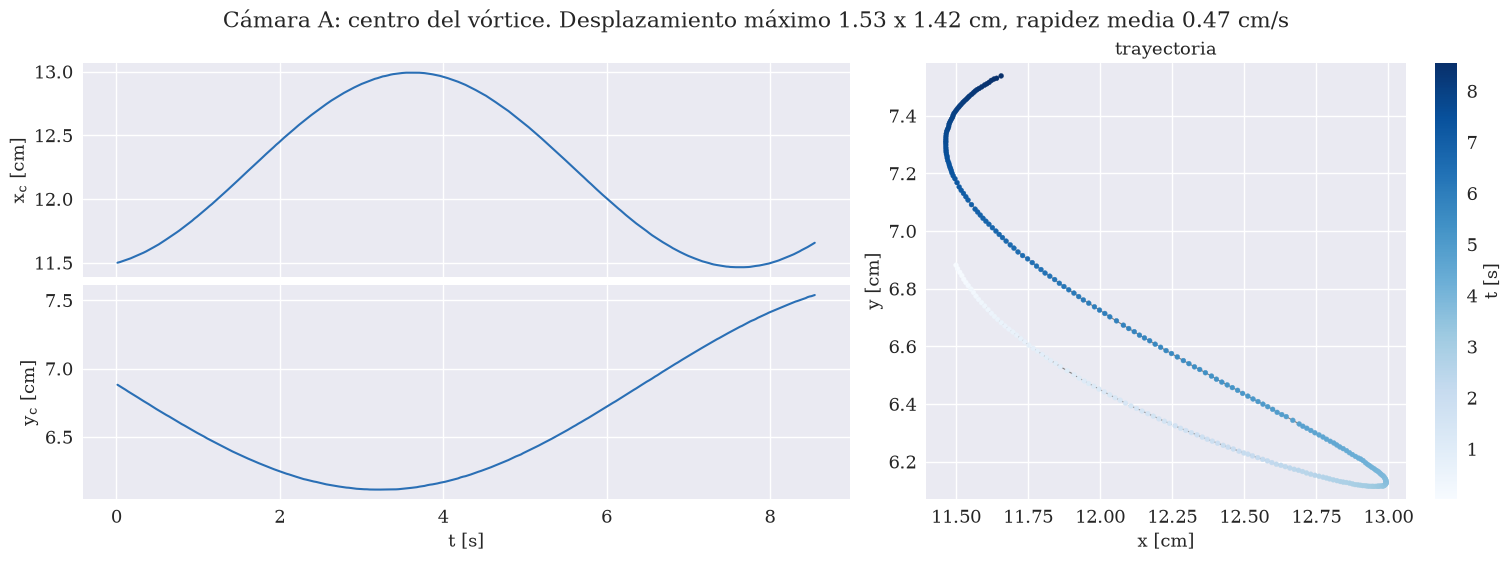

In [3]:
for L, c in camaras.items():
    ce, u = c["centro"], c["unidad"]
    if "t_s" not in ce:
        print(f"cámara {L}: sin _centro.csv (análisis viejo o sin seguimiento): centro fijo.")
        continue
    perdido = ce["seguido"] == 0

    fig = plt.figure(figsize=(15, 5.5), constrained_layout=True)
    grid = fig.add_gridspec(2, 2, width_ratios=[1.6, 1])
    ax_x, ax_y, ax_t = fig.add_subplot(grid[0, 0]), fig.add_subplot(grid[1, 0]), fig.add_subplot(grid[:, 1])

    for ax, col, nombre in ((ax_x, "xc", "x"), (ax_y, "yc", c["eje_vertical"])):
        ax.plot(ce["t_s"], ce[col], lw=1.5, color=AZUL, label="centro")
        ax.plot(ce["t_s"][perdido], ce[col][perdido], "o", ms=4, color=NARANJA, label="partícula no encontrada")
        ax.set_ylabel(f"${nombre}_c$ [{u}]")
    ax_x.tick_params(labelbottom=False)
    ax_y.set_xlabel("t [s]")
    if perdido.any():
        ax_x.legend(fontsize=fontsize - 2)

    puntos = ax_t.scatter(ce["xc"], ce["yc"], c=ce["t_s"], cmap="Blues", s=12)
    ax_t.plot(ce["xc"], ce["yc"], lw=0.8, color="0.5", zorder=0)
    fig.colorbar(puntos, ax=ax_t, label="t [s]")
    ax_t.set_aspect("equal", adjustable="datalim")
    ax_t.set_xlabel(f"x [{u}]")
    ax_t.set_ylabel(f"{c['eje_vertical']} [{u}]")
    ax_t.set_title("trayectoria")

    rapidez = np.hypot(ce["uc"], ce["vc"])
    fig.suptitle(f"Cámara {L}: centro del vórtice. Desplazamiento máximo "
                 f"{np.ptp(ce['xc']):.2f} x {np.ptp(ce['yc']):.2f} {u}, rapidez media {rapidez.mean():.2f} {u}/s")
    plt.show()

## 3. Campo medio

Promedio temporal de todos los pares en cada nodo de la grilla (sistema del laboratorio). A la
izquierda, el módulo de la velocidad con los vectores; a la derecha, la vorticidad normal a la
imagen `∂v/∂x − ∂u/∂y` (en un vórtice de Rankine vale `2ω` en el núcleo y cero afuera).
En rojo, la trayectoria del centro; el círculo punteado es la región analizada.

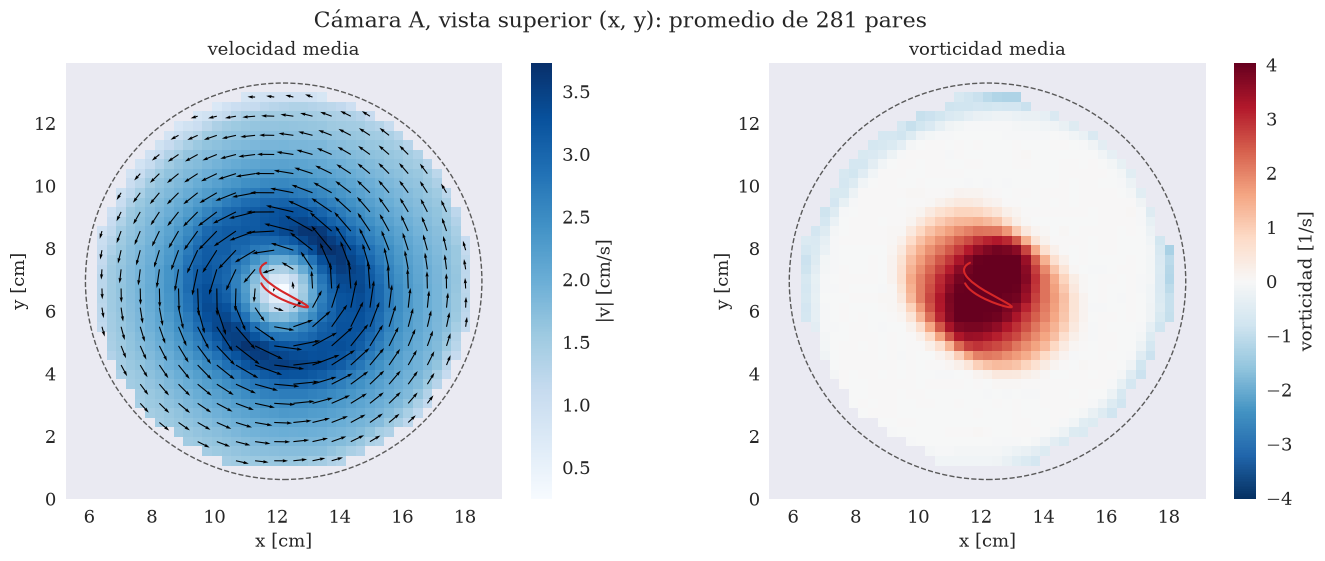

In [4]:
PASO_FLECHAS = 2   # una flecha cada tantos nodos


def grilla(df):
    # Promedio temporal por nodo, como matrices 2D (fila = y, columna = x)
    xs, ys = np.unique(df["x"]), np.unique(df["y"])
    m = df.groupby(["y", "x"])[["u", "v"]].mean().reindex(pd.MultiIndex.from_product([ys, xs]))
    U = m["u"].to_numpy().reshape(len(ys), len(xs))
    V = m["v"].to_numpy().reshape(len(ys), len(xs))
    return xs, ys, U, V


def decorar(ax, c):
    ax.add_patch(plt.Circle((c["cx"], c["cy"]), c["R"], fill=False, ls="--", lw=1, color="0.35"))
    ax.plot(c["centro"]["xc"], c["centro"]["yc"], lw=1.5, color="#D62728")
    ax.set_aspect("equal")
    ax.grid(False)
    ax.set_xlabel(f"x [{c['unidad']}]")
    ax.set_ylabel(f"{c['eje_vertical']} [{c['unidad']}]")


for L, c in camaras.items():
    xs, ys, U, V = grilla(c["df"])
    X, Y = np.meshgrid(xs, ys)
    rapidez = np.hypot(U, V)
    vorticidad = np.gradient(V, xs, axis=1) - np.gradient(U, ys, axis=0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

    im = ax1.pcolormesh(X, Y, rapidez, cmap="Blues", shading="nearest")
    fig.colorbar(im, ax=ax1, label=f"|v| [{c['unidad']}/s]")
    n = PASO_FLECHAS
    escala = np.nanpercentile(rapidez, 95) / (1.5 * n * c["paso"])   # flecha tipica: 1.5 celdas
    ax1.quiver(X[::n, ::n], Y[::n, ::n], U[::n, ::n], V[::n, ::n],
               angles="xy", scale_units="xy", scale=escala, width=0.0025, color="k")
    ax1.set_title("velocidad media")

    lim = np.nanpercentile(np.abs(vorticidad), 98)
    im = ax2.pcolormesh(X, Y, vorticidad, cmap="RdBu_r", vmin=-lim, vmax=lim, shading="nearest")
    fig.colorbar(im, ax=ax2, label="vorticidad [1/s]")
    ax2.set_title("vorticidad media")

    for ax in (ax1, ax2):
        decorar(ax, c)
    fig.suptitle(f"Cámara {L}, vista {c['vista']}: promedio de {c['df']['frame'].nunique()} pares")
    plt.show()

## 4. Campos instantáneos

`N_PANELES` pares repartidos a lo largo de la grabación, todos con la misma escala de flechas.
En naranja, los vectores interpolados; la cruz roja es el centro de ese par.

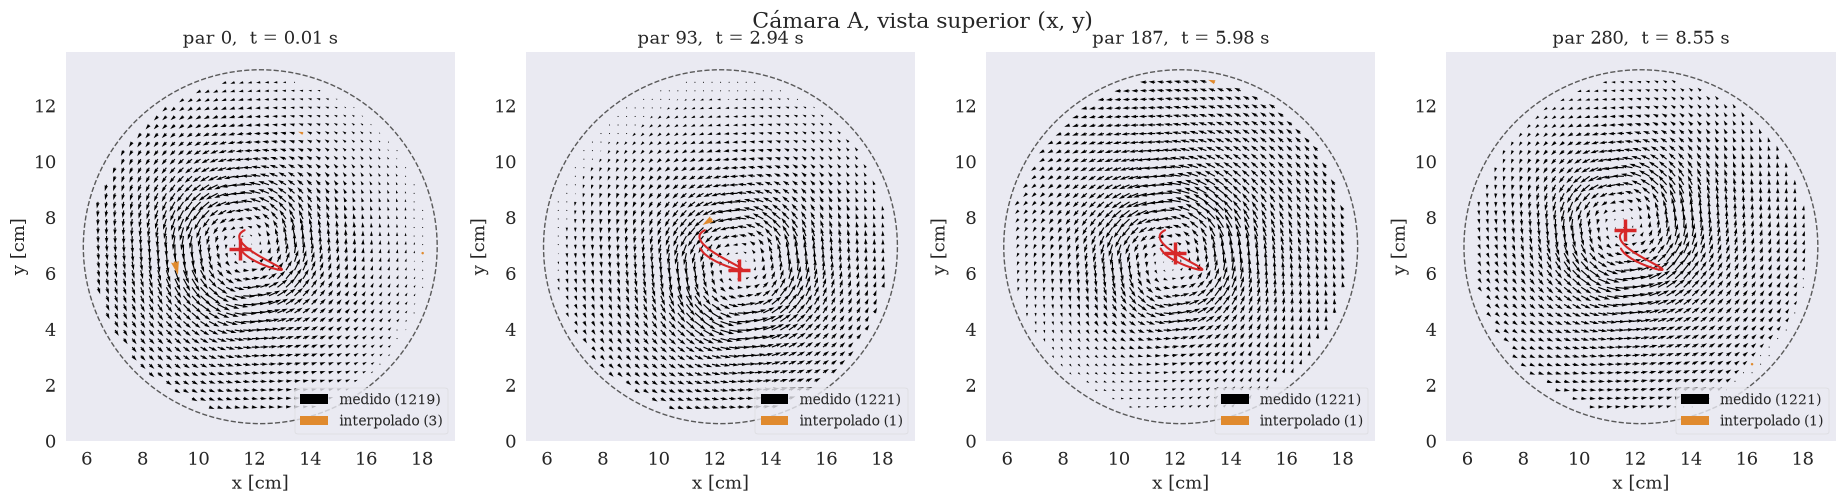

In [5]:
N_PANELES = 4

for L, c in camaras.items():
    todo = c["todo"]
    frames = np.unique(todo["frame"])
    elegidos = frames[np.linspace(0, len(frames) - 1, min(N_PANELES, len(frames))).round().astype(int)]
    escala = np.nanpercentile(np.hypot(todo["u"], todo["v"]), 95) / (1.5 * c["paso"])

    fig, axs = plt.subplots(1, len(elegidos), figsize=(4.6 * len(elegidos), 4.8),
                            constrained_layout=True, squeeze=False)
    for ax, f in zip(axs[0], elegidos):
        d = todo[todo["frame"] == f]
        malo = d["interpolado"] == 1
        for sel, color, ancho, nombre in ((~malo, "k", 0.003, "medido"), (malo, NARANJA, 0.007, "interpolado")):
            ax.quiver(d["x"][sel], d["y"][sel], d["u"][sel], d["v"][sel], angles="xy", scale_units="xy",
                      scale=escala, width=ancho, color=color, label=f"{nombre} ({sel.sum()})")
        decorar(ax, c)
        ax.plot(c["centro"].loc[f, "xc"], c["centro"].loc[f, "yc"], "+", ms=16, mew=2.5, color="#D62728")
        ax.set_title(f"par {f},  t = {d['t_s'].iloc[0]:.2f} s")
        ax.legend(loc="lower right", fontsize=fontsize - 3)
    fig.suptitle(f"Cámara {L}, vista {c['vista']}")
    plt.show()

## 5. Perfil del vórtice (vistas superiores)

El campo se separa en anillos alrededor del centro de cada par, del ancho de una celda de la
grilla. Cada anillo se promedia en cada par y después entre pares. La banda es el desvío
estándar entre pares, o sea cuánto fluctúa en el tiempo.

- `v_θ(r)`: el perfil de velocidad tangencial.
- `ω(r) = v_θ / r`: la velocidad angular, constante en un núcleo que rota como sólido.
- `v_r(r)`: tendría que ser ≈ 0. Si no lo es, el centro está mal o el vórtice se desplaza.

Si la grabación es de la simulación, en gris está el vórtice que se inyectó.

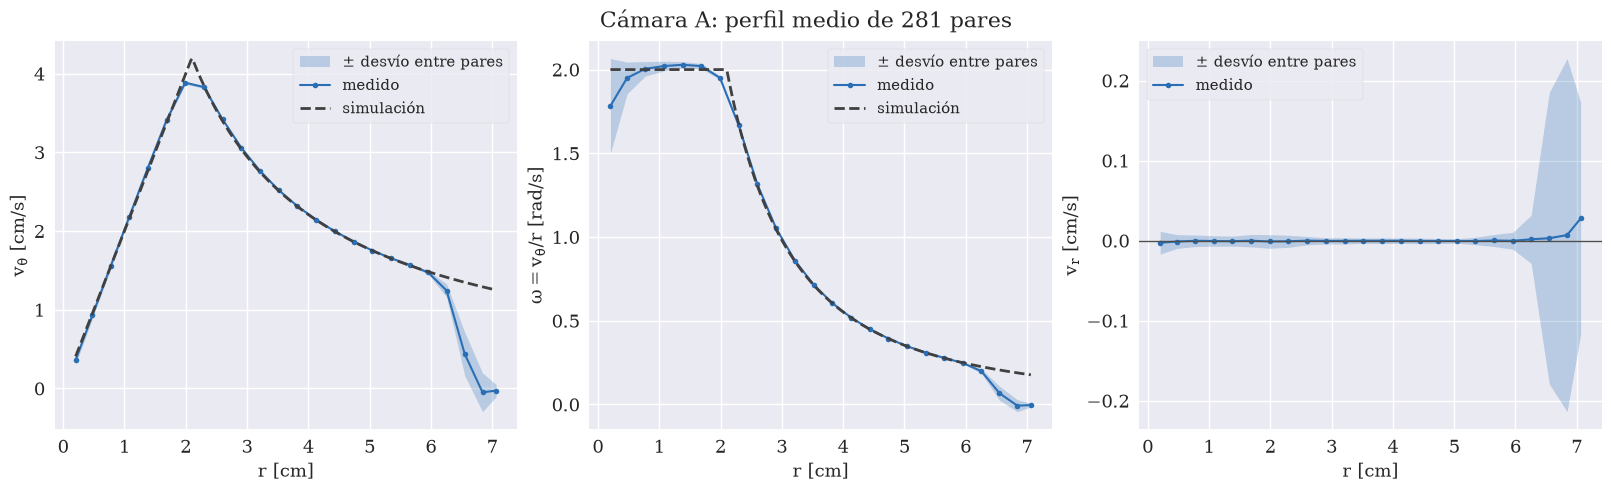

In [6]:
def perfil_por_par(c):
    # v_theta y v_r promediados por anillo en cada par: tabla (anillo, frame)
    df = c["df"].dropna(subset=["vt"])
    anillo = np.floor(df["r"] / c["paso"]).astype(int)
    tabla = df.groupby([anillo, df["frame"]])[["vt", "vr", "t_s"]].mean()
    r = df.groupby(anillo)["r"].mean()
    return r, tabla


def rankine(sim, s, r):
    w0, rc = sim["omega_nucleo_rad_s"], sim["radio_nucleo_px"] * s
    return np.where(r <= rc, w0 * r, w0 * rc**2 / np.maximum(r, rc))


superiores = {L: c for L, c in camaras.items() if "superior" in c["vista"]}
if not superiores:
    print("no hay cámaras con vista superior en este análisis")

perfiles = {}
for L, c in superiores.items():
    u = c["unidad"]
    r, tabla = perfil_por_par(c)
    perfiles[L] = (r, tabla)
    g = tabla.groupby(level=0)
    media, desvio = g.mean(), g.std()

    fig, axs = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
    rr = np.linspace(r.min(), r.max(), 300)
    sim = rankine(c["sim"], c["s"], rr) if c["sim"] else None
    curvas = (   # (medido, desvio, simulacion, nombre, unidad)
        (media["vt"], desvio["vt"], sim, r"$v_\theta$", f"{u}/s"),
        (media["vt"] / r, desvio["vt"] / r, None if sim is None else sim / rr, r"$\omega = v_\theta / r$", "rad/s"),
        (media["vr"], desvio["vr"], None, r"$v_r$", f"{u}/s"),
    )
    for ax, (y, e, teoria, nombre, unidad) in zip(axs, curvas):
        ax.fill_between(r, y - e, y + e, color=AZUL, alpha=0.25, lw=0, label="± desvío entre pares")
        ax.plot(r, y, "o-", ms=4, lw=1.5, color=AZUL, label="medido")
        if teoria is not None:
            ax.plot(rr, teoria, "--", lw=2, color="0.25", label="simulación")
        ax.set_xlabel(f"r [{u}]")
        ax.set_ylabel(f"{nombre} [{unidad}]")
        ax.legend(fontsize=fontsize - 2)
    axs[2].axhline(0, color="0.3", lw=1)
    fig.suptitle(f"Cámara {L}: perfil medio de {tabla.index.get_level_values(1).nunique()} pares")
    plt.show()

## 6. Evolución de v(r)

Arriba, el mapa `v_θ(r, t)`: cada columna es el perfil de un par. Abajo, el perfil promediado en
`N_TRAMOS` tramos de tiempo seguidos (del más claro, al principio, al más oscuro, al final): si
el vórtice es estacionario las curvas se superponen; si se frena o se ensancha, se ve acá.

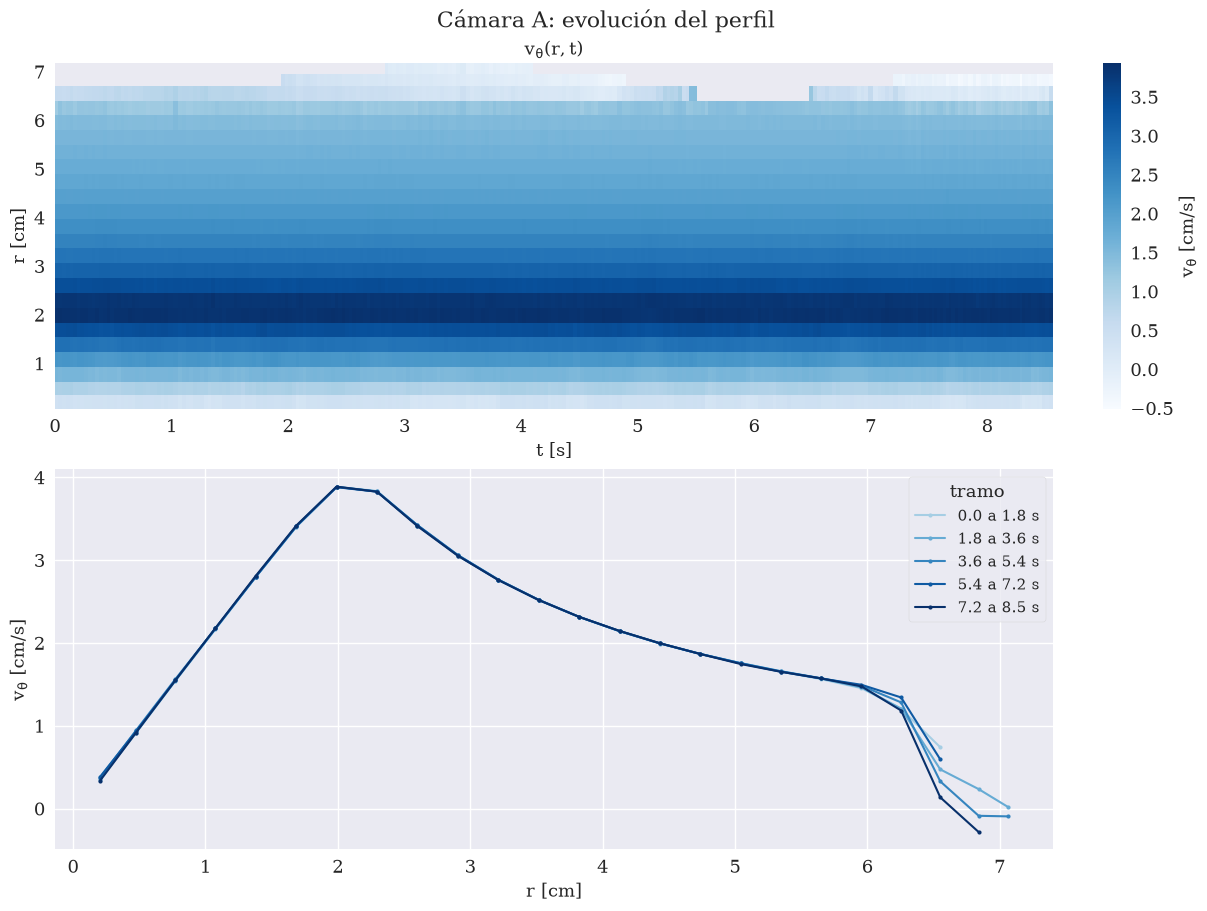

In [7]:
N_TRAMOS = 5

for L, (r, tabla) in perfiles.items():
    c, u = camaras[L], camaras[L]["unidad"]
    mapa = tabla["vt"].unstack(level=0)          # filas = pares, columnas = anillos
    t = tabla["t_s"].groupby(level=1).mean()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), constrained_layout=True,
                                   gridspec_kw={"height_ratios": [1, 1.1]})
    im = ax1.pcolormesh(t.loc[mapa.index], r.loc[mapa.columns], mapa.T, cmap="Blues", shading="nearest")
    fig.colorbar(im, ax=ax1, label=rf"$v_\theta$ [{u}/s]")
    ax1.grid(False)
    ax1.set_xlabel("t [s]")
    ax1.set_ylabel(f"r [{u}]")
    ax1.set_title(rf"$v_\theta(r, t)$")

    frames = np.array(mapa.index)
    tramos = np.array_split(frames, min(N_TRAMOS, len(frames)))
    colores = plt.cm.Blues(np.linspace(0.35, 1.0, len(tramos)))
    for tramo, color in zip(tramos, colores):
        perfil = mapa.loc[tramo].mean()
        ax2.plot(r.loc[perfil.index], perfil, "o-", ms=3, lw=1.5, color=color,
                 label=f"{t.loc[tramo[0]]:.1f} a {t.loc[tramo[-1]]:.1f} s")
    ax2.set_xlabel(f"r [{u}]")
    ax2.set_ylabel(rf"$v_\theta$ [{u}/s]")
    ax2.legend(title="tramo", fontsize=fontsize - 2)
    fig.suptitle(f"Cámara {L}: evolución del perfil")
    plt.show()

## 7. Calidad en el tiempo

Para cada cámara, par a par: la rapidez media dentro de la región analizada, y el porcentaje de
vectores interpolados. Un salto en el segundo indica que en ese momento la imagen empeoró
(poco glitter, reflejos, desenfoque).

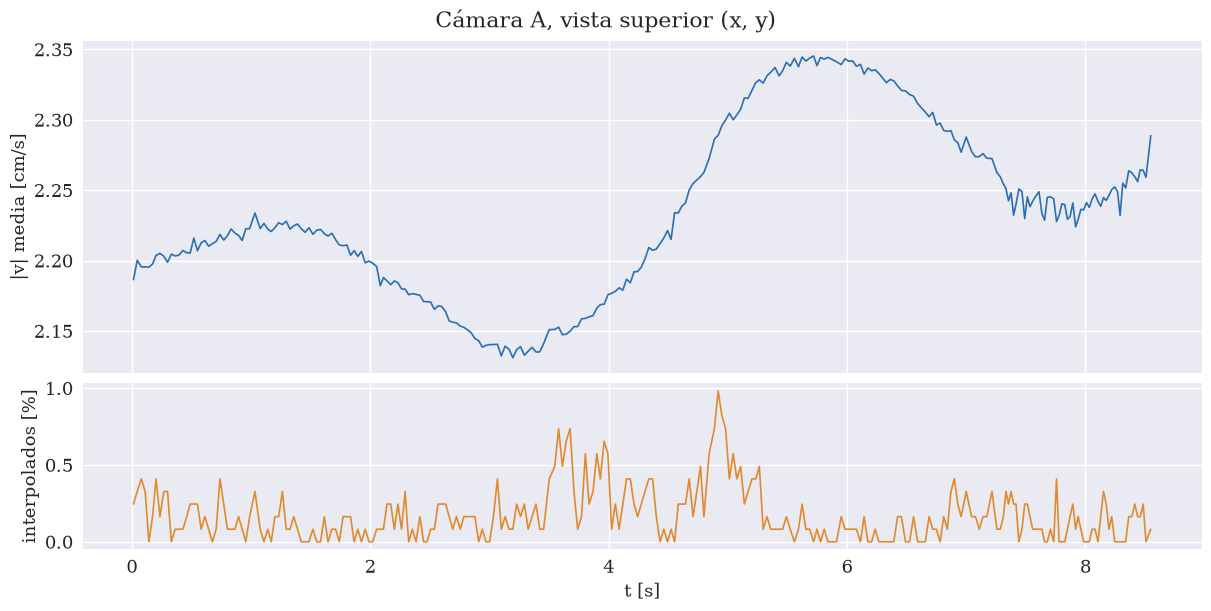

In [8]:
for L, c in camaras.items():
    por_par = c["todo"].groupby("frame").agg(t=("t_s", "mean"), interpolado=("interpolado", "mean"))
    rapidez = np.hypot(c["df"]["u"], c["df"]["v"]).groupby(c["df"]["frame"]).mean()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True, constrained_layout=True,
                                   gridspec_kw={"height_ratios": [2, 1]})
    ax1.plot(por_par["t"].loc[rapidez.index], rapidez, lw=1.2, color=AZUL)
    ax1.set_ylabel(f"|v| media [{c['unidad']}/s]")
    ax2.plot(por_par["t"], 100 * por_par["interpolado"], lw=1.2, color=NARANJA)
    ax2.set_ylabel("interpolados [%]")
    ax2.set_xlabel("t [s]")
    fig.suptitle(f"Cámara {L}, vista {c['vista']}")
    plt.show()